In [62]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Config
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

In [63]:
# Datasets
datasets = [
    'dataset1/',
    'dataset2/',
    'dataset3/'
]

folders = [
    'EarliestSetting5tele',
    'Random5tele',
    'ShortestSlew5tele',
    'tsp5',
    'tspcRoundRobin5',
    'tspcLoadBal5',
    'tspcKmean5'
]

folder_name_map = {
    "EarliestSetting5tele": "Earliest Setting",
    "Random5tele": "Random",
    "ShortestSlew5tele": "Shortest Slew",
    "tsp5": "MTSP (Gurobi)",
    "tspcRoundRobin5": "MTSP (Round Robin Partitioning)",
    "tspcLoadBal5": "MTSP (Load Balance Partitioning)",
    "tspcKmean5": "MTSP (K-Means Partitioning)"
}

dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')

    stats_list = []

    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)

        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")

        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
                df = df.iloc[0:5]

                if 'No' in df.columns:
                    df['No'] = pd.to_numeric(df['No'], errors='coerce')
                    tot_time = df['No'].max()

                    stats_list.append({
                        'File': os.path.basename(file),
                        'Folder': folder_name,
                        'Total Time': tot_time
                    })
                else:
                    print(f"'No' column not found in {file}")
            except Exception as e:
                print(f"Error processing {file}: {e}")

    # Convert to DataFrames
    dataset_df = pd.DataFrame(stats_list)
    dataset_dfs[dataset_name] = dataset_df


Processing dataset1 - Earliest Setting with 10 files.
Processing dataset1 - Random with 10 files.
Processing dataset1 - Shortest Slew with 10 files.
Processing dataset1 - MTSP (Gurobi) with 10 files.
Processing dataset1 - MTSP (Round Robin Partitioning) with 3 files.
Processing dataset1 - MTSP (Load Balance Partitioning) with 1 files.
Processing dataset1 - MTSP (K-Means Partitioning) with 6 files.
Processing dataset2 - Earliest Setting with 10 files.
Processing dataset2 - Random with 10 files.
Processing dataset2 - Shortest Slew with 10 files.
Processing dataset2 - MTSP (Gurobi) with 10 files.
Processing dataset2 - MTSP (Round Robin Partitioning) with 0 files.
Processing dataset2 - MTSP (Load Balance Partitioning) with 0 files.
Processing dataset2 - MTSP (K-Means Partitioning) with 10 files.
Processing dataset3 - Earliest Setting with 10 files.
Processing dataset3 - Random with 10 files.
Processing dataset3 - Shortest Slew with 10 files.
Processing dataset3 - MTSP (Gurobi) with 10 file

In [64]:
for name, df in dataset_dfs.items():
    summary = df.groupby('Folder')['Total Time'].agg(['min', 'max', 'mean']).reset_index()
    print(f"Statistics for {name}:")
    print(summary)
    print()


Statistics for dataset1:
                             Folder        min        max       mean
0                  Earliest Setting  12.082500  15.539167  13.523667
1                     MTSP (Gurobi)  12.131389  20.667222  14.669056
2       MTSP (K-Means Partitioning)  14.765556  21.563333  17.449676
3  MTSP (Load Balance Partitioning)  20.271667  20.271667  20.271667
4   MTSP (Round Robin Partitioning)  25.455833  26.419722  26.008981
5                            Random  15.053889  26.536667  18.236361
6                     Shortest Slew  11.691944  15.330833  13.577111

Statistics for dataset2:
                        Folder        min        max       mean
0             Earliest Setting  30.171389  38.487778  34.776194
1                MTSP (Gurobi)  30.081667  41.691944  35.160861
2  MTSP (K-Means Partitioning)  41.045556  50.376667  44.628722
3                       Random  31.245278  39.139444  35.153222
4                Shortest Slew  28.500278  52.818889  34.900917

Statistics f

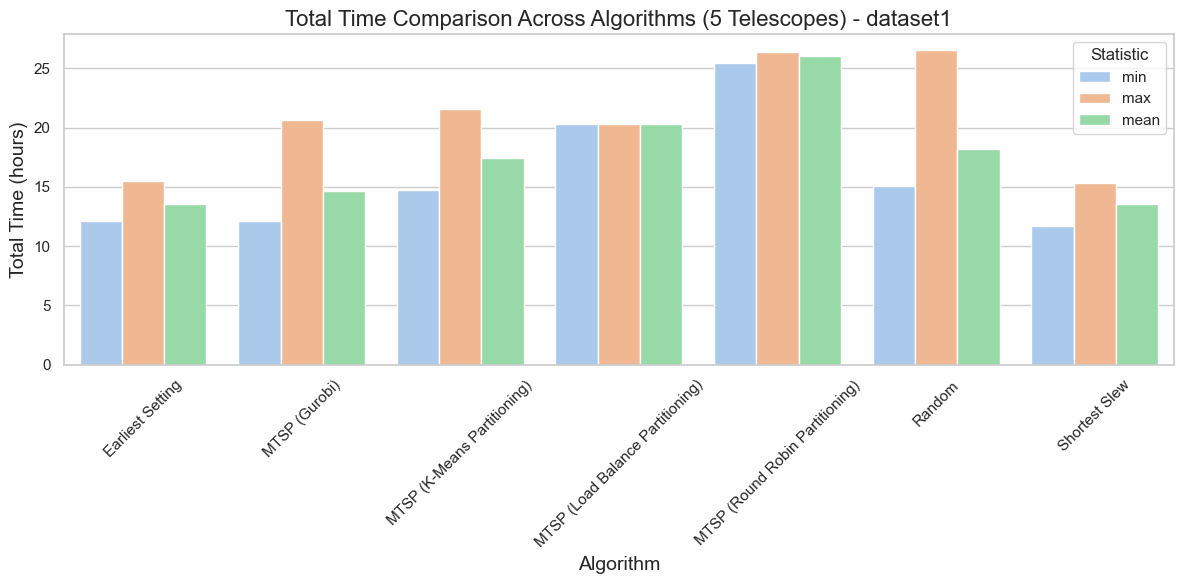

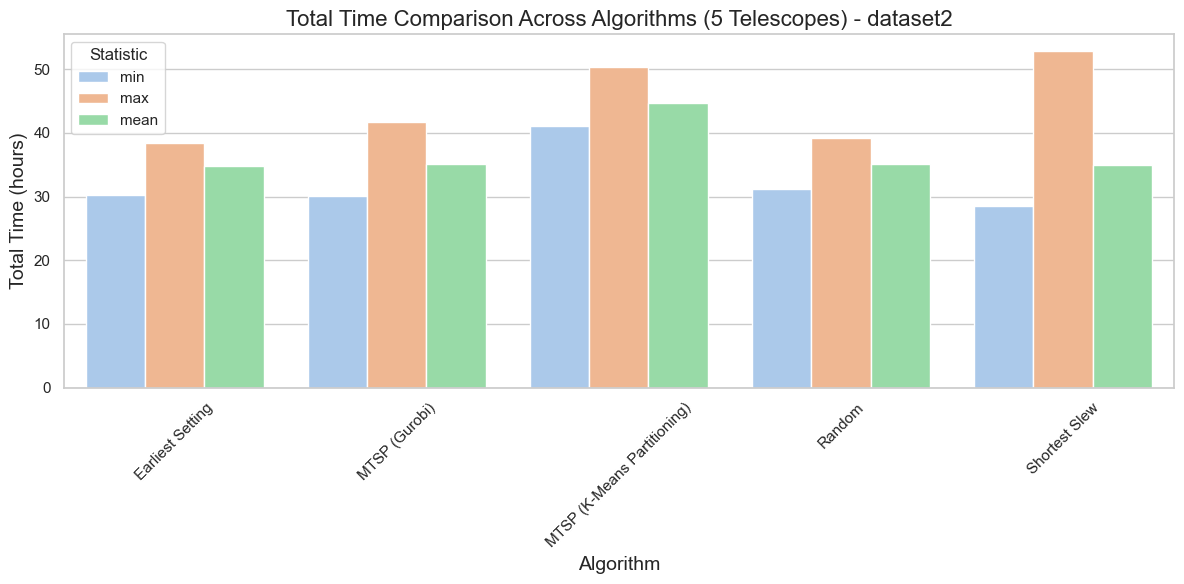

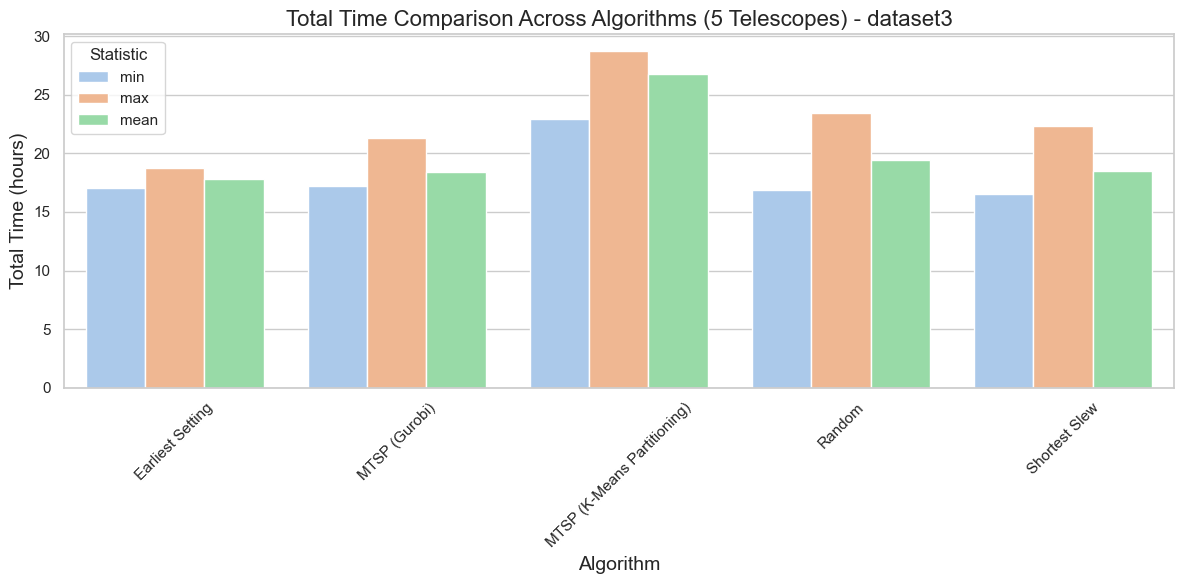

In [66]:
# Data Plot with Bar Graph
for dataset_name, df in dataset_dfs.items():
    if df.empty:
        print(f"Skipping {dataset_name} because it has no data.")
        continue

    folder_summary = df.groupby('Folder')['Total Time'].agg(['min', 'max', 'mean']).reset_index()
    folder_summary_melt = folder_summary.melt(
        id_vars='Folder',
        value_vars=['min', 'max', 'mean'],
        var_name='Statistic',
        value_name='Total Time'
    )

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=folder_summary_melt,
        x='Folder',
        y='Total Time',
        hue='Statistic'
    )

    plt.title(f"Total Time Comparison Across Algorithms (5 Telescopes) - {dataset_name}", fontsize=16)
    plt.ylabel("Total Time (hours)", fontsize=14)
    plt.xlabel("Algorithm", fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(title="Statistic")
    plt.tight_layout()
    plt.show()
